In [1]:
import sys, os
sys.path.insert(0, '/home/aiscuser/verl')

In [2]:
from verl.trainer.ppo.ray_trainer import RayPPOTrainer
import ray
import hydra
import torch
from verl.utils.fs import copy_to_local
from pprint import pprint
from omegaconf import OmegaConf
from verl.trainer.main_ppo import *
from verl.utils import hf_tokenizer, hf_processor
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
from verl import DataProto
from codetiming import Timer
import matplotlib.pyplot as plt

/opt/conda/envs/ptca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-11 07:31:32,030	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [49]:
ray.init()

2025-04-11 08:07:40,778	INFO worker.py:1660 -- Connecting to existing Ray cluster at address: node-0:6379...
2025-04-11 08:07:40,871	INFO worker.py:1843 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 


Python version:,3.10.14
Ray version:,2.44.0
Dashboard:,http://127.0.0.1:8265


In [50]:
config = '/home/aiscuser/verl/verl/trainer/config/dapo_qwen2.5_7b.yaml'
config = OmegaConf.load(config)
OmegaConf.resolve(config)

In [51]:
local_path = copy_to_local(config.actor_rollout_ref.model.path)
tokenizer = hf_tokenizer(local_path)
processor = hf_processor(local_path, use_fast=True)  # used for multimodal LLM, could be none

# define worker classes
if config.actor_rollout_ref.actor.strategy == 'fsdp':
    assert config.actor_rollout_ref.actor.strategy == config.critic.strategy
    from verl.workers.fsdp_workers import ActorRolloutRefWorker, CriticWorker
    from verl.single_controller.ray import RayWorkerGroup
    ray_worker_group_cls = RayWorkerGroup

from verl.trainer.ppo.ray_trainer import ResourcePoolManager, Role

role_worker_mapping = {
    Role.ActorRollout: ray.remote(ActorRolloutRefWorker),
    Role.Critic: ray.remote(CriticWorker),
    Role.RefPolicy: ray.remote(ActorRolloutRefWorker)
}

global_pool_id = 'global_pool'
resource_pool_spec = {
    global_pool_id: [config.trainer.n_gpus_per_node] * config.trainer.nnodes,
}
mapping = {
    Role.ActorRollout: global_pool_id,
    Role.Critic: global_pool_id,
    Role.RefPolicy: global_pool_id,
}
if config.reward_model.enable:
    if config.reward_model.strategy == 'fsdp':
        from verl.workers.fsdp_workers import RewardModelWorker
    elif config.reward_model.strategy == 'megatron':
        from verl.workers.megatron_workers import RewardModelWorker
    else:
        raise NotImplementedError
    role_worker_mapping[Role.RewardModel] = ray.remote(RewardModelWorker)
    mapping[Role.RewardModel] = global_pool_id

reward_manager_name = config.reward_model.get("reward_manager", "naive")
if reward_manager_name == 'naive':
    from verl.workers.reward_manager import NaiveRewardManager
    reward_manager_cls = NaiveRewardManager
elif reward_manager_name == 'prime':
    from verl.workers.reward_manager import PrimeRewardManager
    reward_manager_cls = PrimeRewardManager
elif reward_manager_name == 'dapo':
    from verl.workers.reward_manager import DAPORewardManager
    reward_manager_cls = DAPORewardManager
else:

    raise NotImplementedError

compute_score = get_custom_reward_fn(config)
reward_fn = reward_manager_cls(tokenizer=tokenizer,
                                num_examine=0,
                                compute_score=compute_score,
                                reward_fn_key=config.data.reward_fn_key)

# Note that we always use function-based RM for validation
val_reward_fn = reward_manager_cls(tokenizer=tokenizer,
                                    num_examine=1,
                                    compute_score=compute_score,
                                    reward_fn_key=config.data.reward_fn_key)
resource_pool_manager = ResourcePoolManager(resource_pool_spec=resource_pool_spec, mapping=mapping)

trainer = RayPPOTrainer(config=config,
                        tokenizer=tokenizer,
                        processor=processor,
                        role_worker_mapping=role_worker_mapping,
                        resource_pool_manager=resource_pool_manager,
                        ray_worker_group_cls=ray_worker_group_cls,
                        reward_fn=reward_fn,
                        val_reward_fn=val_reward_fn)
trainer.init_workers()

[validate_config] All configuration checks passed successfully!
dataset len: 1791700
dataset len: 960
Size of train dataloader: 1749
Total training steps: 174900


(pid=552859, ip=10.1.38.158) /opt/nvidia/Megatron-LM/megatron/core/transformer/cuda_graphs.py:741: SyntaxWarning: assertion is always true, perhaps remove parentheses?
(pid=552859, ip=10.1.38.158)   assert (


(pid=552859, ip=10.1.38.158) INFO 04-11 08:07:59 __init__.py:190] Automatically detected platform cuda.


(pid=553019, ip=10.1.38.158) /opt/nvidia/Megatron-LM/megatron/core/transformer/cuda_graphs.py:741: SyntaxWarning: assertion is always true, perhaps remove parentheses?
(pid=553019, ip=10.1.38.158)   assert (
(pid=553020, ip=10.1.38.158) /opt/nvidia/Megatron-LM/megatron/core/transformer/cuda_graphs.py:741: SyntaxWarning: assertion is always true, perhaps remove parentheses?
(pid=553020, ip=10.1.38.158)   assert (


(pid=553019, ip=10.1.38.158) INFO 04-11 08:08:09 __init__.py:190] Automatically detected platform cuda.
(pid=553020, ip=10.1.38.158) INFO 04-11 08:08:10 __init__.py:190] Automatically detected platform cuda.


...

(WorkerDict pid=552859, ip=10.1.38.158) [W411 08:10:05.359377285 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
(WorkerDict pid=552859, ip=10.1.38.158) [W411 08:10:05.405651634 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())


(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO Bootstrap : Using eth0:10.1.38.158<0>
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO NET/Plugin: Failed to find ncclNetPlugin_v8 symbol.
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO NET/Plugin: Loaded net plugin NCCL RDMA Plugin v6 (v6)
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin_v8 symbol.
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin symbol (>= v5). ncclCollNetPlugin symbols v4 and lower are not supported.
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554943:554943 [0] NCCL INFO cudaDriverVersion 12040
(WorkerDict pid=552859, ip=10.1.38.158) NCCL version 2.21.5+cuda12.4
(WorkerDict pid=552859, ip=10.1.38.158) node-1:554945:554945 [2] NCCL INFO Plugin Path : /opt/nccl-rdma-sharp-plugins/lib/libnccl-net.so


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
(WorkerDict pid=553019, ip=10.1.38.158) [W411 08:10:06.384048080 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator()) [repeated 6x across cluster]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:00,  3.63it/s]
(WorkerDict pid=552859, ip=10.1.38.158) 
(WorkerDict pid=553019, ip=10.1.38.158) 
  5%|▌         | 1/19 [00:01<00:22,  1.27s/it]0m 
Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  3.78it/s] [repeated 9x across cluster]
100%|██████████| 19/19 [00:06<00:00,  2.76it/s]m 


(WorkerDict pid=553019, ip=10.1.38.158) kwargs: {'n': 1, 'max_new_tokens': 8192, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': False}
(WorkerDict pid=553019, ip=10.1.38.158) node-1:554955:554955 [3] NCCL INFO Bootstrap : Using eth0:10.1.38.158<0> [repeated 7x across cluster]
(WorkerDict pid=553019, ip=10.1.38.158) node-1:554955:554955 [3] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin_v8 symbol. [repeated 14x across cluster]
(WorkerDict pid=553019, ip=10.1.38.158) node-1:554955:554955 [3] NCCL INFO NET/Plugin: Loaded net plugin NCCL RDMA Plugin v6 (v6) [repeated 7x across cluster]
(WorkerDict pid=553019, ip=10.1.38.158) node-1:554955:554955 [3] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin symbol (>= v5). ncclCollNetPlugin symbols v4 and lower are not supported. [repeated 7x across cluster]
(WorkerDict pid=553019, ip=10.1.38.158) node-1:554955:554955 [3] NCCL INFO cudaDriverVer

(WorkerDict pid=553019, ip=10.1.38.158) /opt/conda/envs/ptca/lib/python3.10/site-packages/torch/distributed/fsdp/fully_sharded_data_parallel.py:690: FutureWarning: FSDP.state_dict_type() and FSDP.set_state_dict_type() are being deprecated. Please use APIs, get_state_dict() and set_state_dict(), which can support different parallelisms, FSDP1, FSDP2, DDP. API doc: https://pytorch.org/docs/stable/distributed.checkpoint.html#torch.distributed.checkpoint.state_dict.get_state_dict .Tutorial: https://pytorch.org/tutorials/recipes/distributed_checkpoint_recipe.html .
(WorkerDict pid=553019, ip=10.1.38.158)   warnings.warn(
(WorkerDict pid=552859, ip=10.1.38.158) /opt/conda/envs/ptca/lib/python3.10/site-packages/torch/distributed/fsdp/fully_sharded_data_parallel.py:690: FutureWarning: FSDP.state_dict_type() and FSDP.set_state_dict_type() are being deprecated. Please use APIs, get_state_dict() and set_state_dict(), which can support different parallelisms, FSDP1, FSDP2, DDP. API doc: https://py

## Profiling batch size

In [24]:
def get_batch(batch_size):  
    data = trainer.train_dataloader.dataset[0]
    batch = [data for _ in range(batch_size)]
    batch = collate_fn(batch)
    batch = DataProto.from_single_dict(batch)
    gen_batch = batch.pop(
    batch_keys=['input_ids', 'attention_mask', 'position_ids'],
    non_tensor_batch_keys=['raw_prompt_ids'],
    )
    sampling_params = {
        'do_sample': True,
        'max_new_tokens': 1024,
        'min_new_tokens': 1023,
        'ignore_eos': True,
        'n': 1
    }
    gen_batch.meta_info['sampling_params'] = sampling_params
    return gen_batch

batch_size = 128
gen_batch = get_batch(batch_size)

In [25]:
timer = Timer('generate_sequences')
with timer:
    trainer.actor_rollout_wg.generate_sequences(gen_batch)

Elapsed time: 13.6019 seconds


In [17]:
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024]
elapsed_times = {}
for batch_size in batch_sizes:
    gen_batch = get_batch(batch_size)
    timer = Timer('generate_sequences')
    with timer:
        trainer.actor_rollout_wg.generate_sequences(gen_batch)
    elapsed_times[batch_size] = timer.last

(WorkerDict pid=542757) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True}
(WorkerDict pid=542757) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 8x across cluster]
(WorkerDict pid=542757) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 8x across cluster]
(WorkerDict pid=542757) self.sampling_params={'n': 1, 'max_new_tokens': 1024, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': True} [repeated 8x across cluster]
(WorkerDict pid=54275

Elapsed time: 7.7657 seconds
Elapsed time: 8.5951 seconds
Elapsed time: 9.5477 seconds
Elapsed time: 11.3714 seconds
Elapsed time: 12.7742 seconds
Elapsed time: 18.4757 seconds
Elapsed time: 34.3143 seconds
Elapsed time: 64.5454 seconds


### Compiled

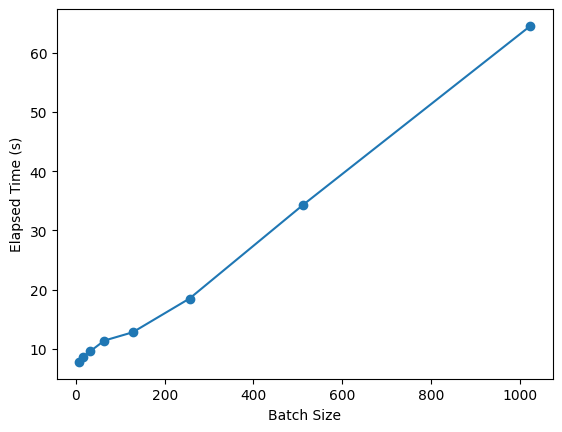

In [19]:
# Plot the elapsed time
plt.scatter(batch_sizes, elapsed_times.values())
plt.plot(batch_sizes, elapsed_times.values())
plt.xlabel('Batch Size')
plt.ylabel('Elapsed Time (s)')
plt.show()

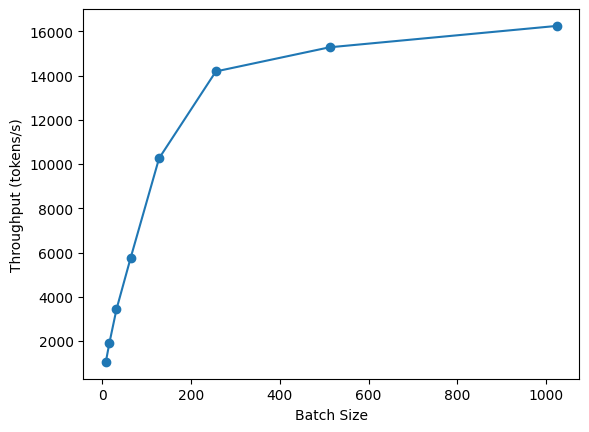

In [22]:
# Throughput
throughputs = []
for batch_size in batch_sizes:
    throughput = batch_size * 1024 / elapsed_times[batch_size]
    throughputs.append(throughput)
plt.scatter(batch_sizes, throughputs)
plt.plot(batch_sizes, throughputs)
plt.xlabel('Batch Size')
plt.ylabel('Throughput (tokens/s)')
plt.show()

### Non-compiled

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


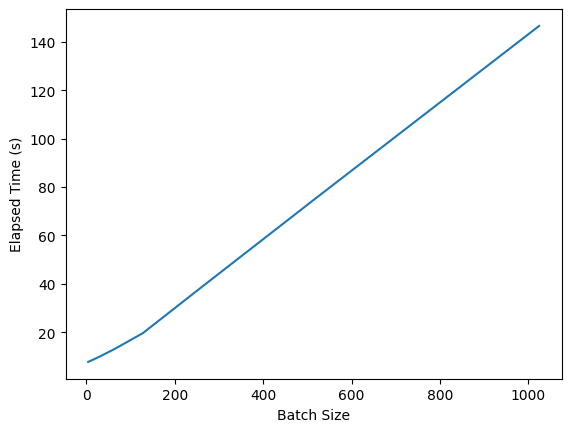

In [ ]:
# Plot the elapsed time
plt.plot(batch_sizes, elapsed_times.values())
plt.xlabel('Batch Size')
plt.ylabel('Elapsed Time (s)')
plt.show()

In [24]:
def get_batch(batch_size, gen_len, deterministic=False, macro_batch=False):
    data = trainer.train_dataloader.dataset[0]
    batch = [data for _ in range(batch_size)]
    batch = collate_fn(batch)
    batch = DataProto.from_single_dict(batch)
    if macro_batch:
        gids = torch.arange(batch_size)
        batch.batch['gids'] = gids
        gen_batch = batch.pop(
        batch_keys=['input_ids', 'attention_mask', 'position_ids', 'gids'],
        non_tensor_batch_keys=['raw_prompt_ids'],
        )
    else:
        gen_batch = batch.pop(
        batch_keys=['input_ids', 'attention_mask', 'position_ids'],
        non_tensor_batch_keys=['raw_prompt_ids'],
        )
    sampling_params = {
        'do_sample': True,
        'max_new_tokens': gen_len,
        'min_new_tokens': gen_len - 1 if deterministic else 1,
        'ignore_eos': True,
        'n': 1
    }
    gen_batch.meta_info['sampling_params'] = sampling_params
    return gen_batch

## Ingroup test

In [52]:
batch = get_batch(128, 1024, False, True)
batch.meta_info['group_shuffle'] = True
batch.meta_info['n_groups'] = 4
trainer.actor_rollout_wg.feed_group_cache(batch)

(WorkerDict pid=552859, ip=10.1.38.158) kwargs: {'n': 1, 'max_new_tokens': 8192, 'presence_penalty': 0.0, 'frequency_penalty': 0.0, 'repetition_penalty': 1.0, 'temperature': 1.0, 'top_k': -1, 'top_p': 1.0, 'ignore_eos': False}
(WorkerDict pid=552859, ip=10.1.38.158) After building sglang rollout, memory allocated (GB): 3.5471715927124023, memory reserved (GB): 19.66015625
(WorkerDict pid=552859, ip=10.1.38.158) After building sharding manager, memory allocated (GB): 3.5471715927124023, memory reserved (GB): 19.66015625
(WorkerDict pid=553019, ip=10.1.38.158) 4604 [0] NCCL INFO Channel 07/0 : 4[4] -> 7[7] via P2P/IPC/read
(WorkerDict pid=553019, ip=10.1.38.158) node-1:553019:554604 [0] NCCL INFO Channel 08/0 : 4[4] -> 7[7] via P2P/IPC/read
(WorkerDict pid=553019, ip=10.1.38.158) node-1:553019:554604 [0] NCCL INFO Channel 09/0 : 4[4] -> 7[7] via P2P/IPC/read
(WorkerDict pid=553019, ip=10.1.38.158) node-1:553019:554604 [0] NCCL INFO Channel 10/0 : 4[4] -> 7[7] via P2P/IPC/read
(WorkerDict

(WorkerDict pid=552859, ip=10.1.38.158) /home/aiscuser/verl/verl/utils/distributed.py:37: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
(WorkerDict pid=552859, ip=10.1.38.158)   storage = torch.ByteStorage.from_buffer(buffer)


DataProto(batch=None, non_tensor_batch={}, meta_info={})

In [56]:
timer = Timer('generate_sequences_ingroup')
with timer:
    output = trainer.actor_rollout_wg.generate_sequences_ingroup()

Elapsed time: 51.8521 seconds


In [57]:
ray.shutdown()